<a href="https://colab.research.google.com/github/Pranesh-M-2006/Mechine-learning/blob/main/Exp%202/Scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
df = pd.read_csv("/content/bottle.csv")   # CalCOFI dataset file


In [6]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53338 entries, 0 to 53337
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cst_Cnt              53338 non-null  int64  
 1   Btl_Cnt              53338 non-null  int64  
 2   Sta_ID               53338 non-null  object 
 3   Depth_ID             53338 non-null  object 
 4   Depthm               53338 non-null  int64  
 5   T_degC               53027 non-null  float64
 6   Salnty               51856 non-null  float64
 7   O2ml_L               48852 non-null  float64
 8   STheta               51589 non-null  float64
 9   O2Sat                47358 non-null  float64
 10  Oxy_µmol/Kg          47357 non-null  float64
 11  BtlNum               0 non-null      float64
 12  RecInd               53337 non-null  float64
 13  T_prec               53026 non-null  float64
 14  T_qual               479 non-null    float64
 15  S_prec               51855 non-null 

In [8]:
features = ['Depthm', 'Salnty', 'O2ml_L']
target = 'T_degC'

data = df[features + [target]]

In [9]:
data = data.fillna(data.median())


In [10]:
data.isnull().sum()


,0
Depthm,0
Salnty,0
O2ml_L,0
T_degC,0


In [11]:
X = data[features]
y = data[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [14]:
y_pred = model.predict(X_test)


In [15]:
mse = mean_squared_error(y_test, y_pred)


In [16]:
rmse = np.sqrt(mse)


In [17]:
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 4.540634797840479
RMSE: 2.1308765327537116
R2 Score: 0.7529359122541351


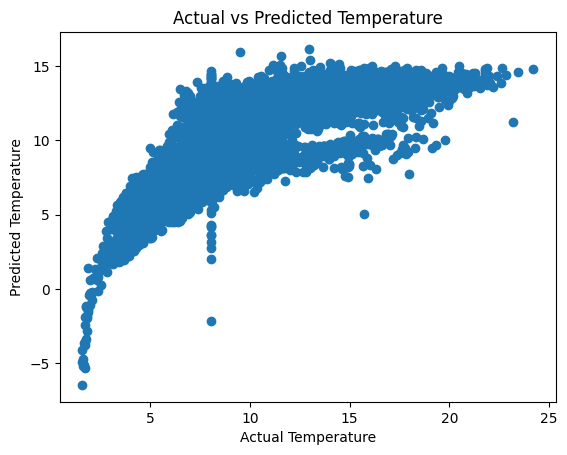

In [18]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()


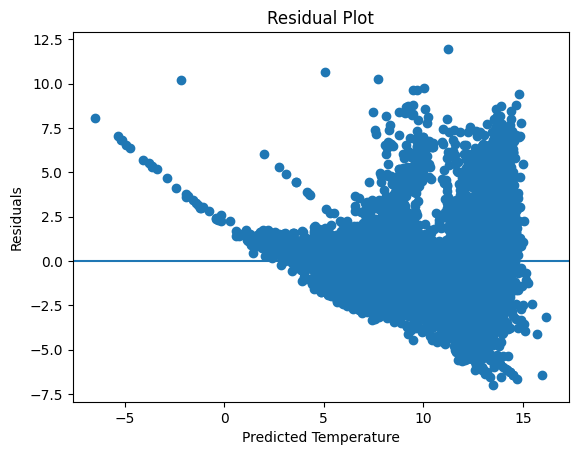

In [19]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Temperature")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


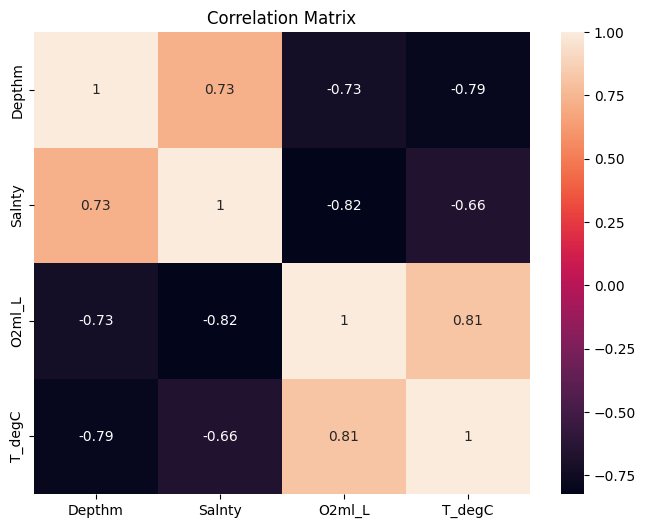

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


In [21]:
features = ['Depthm', 'Salnty', 'O2ml_L']   # Example refined features


In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))


Ridge R2: 0.7529353056697359


In [23]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))


Lasso R2: 0.7433857969089782
